## DATA 620 - Week 2 Centrality Measures
Denise Atherley

## Project Title
Centrality Measures of John Padgett's Florentine Families


## Introduction:
For this assignment, I identified an interesting set of network data available directly into Python's NetworkX library called the "Florentine Families" dataset. This dataset maps the relationships between powerful families in 15th Century Florence during the rise of the Medici. It consists of 15 nodes, which represent the elite Renaissance families, and edges, which represent the marriage alliances and business ties.

The standard baseline dataset provides "Wealth" and "Priorates" as variables but the dataset will need to be extended to include historical Political Faction as the categorical variable to fulfill the requirement of this assignment.

## High Level Plan:
### Acquire the Data
In order to acquire the data for this assignment, I will call the API using G = nx.florentine_families_graph() to load the marriage network.

### Address Categorical Variable
Because the default NetworkX pull does not include the political factions, I will manually inject the categorical variable mapping each family to their historical faction. I will use nx.set_node_attributes(G, faction_mapping, 'faction') to assign the categorical labels to my graph nodes.

### Calculate Centrality Measures, Compare and Analyze
I will use nx.degree_centrality(G) to calculate the degree centrality for every node and extract the family names, their assigned faction and their centrality scores into a clean pandas DataFrame. I will then use the groupby() function on my DataFrame to group the data by the faction category and calculate the average degree centrality for each political side.

## Hypothetical Outcome & Prediction
Degree centrality measures the sheer volume of direct connections a node has. In this context, a high score means a family has marriage alliances with many other families.

Hypothetical Prediction: You could predict that families categorized in the "Medici Faction" will exhibit a significantly higher average degree centrality than families in the "Oligarch Faction".

Why? Historically, Cosimo de' Medici engineered his family's rise to power not by having the most money, but by strategically marrying into a diverse, star-shaped web of both elite and newly wealthy families. Because the Medici systematically positioned themselves as the central hub of these marriage alliances, their faction would naturally display higher degree centrality. 

## References:
Padgett, J. F., & Ansell, C. K. (1993). Robust action and the rise of the Medici, 1400-1434. American Journal of Sociology, 98, 1259–1319. https://doi.org/10.1086/230190

## Setup and Data Loading
I will load the base graph and use nx.set_node_attributes to map each family to their historical faction, creating the categorical groups required for the t-test.

In [6]:
import networkx as nx
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load Padgett's Florentine Families marriage graph
G = nx.florentine_families_graph()

# Inject categorical variable representing the two primary historical rival factions
faction_mapping = {
    'Medici': 'Medici', 'Tornabuoni': 'Medici', 
    'Salviati': 'Medici', 'Acciaiuoli': 'Medici',
    'Ginori': 'Medici',
    'Strozzi': 'Oligarch', 'Albizzi': 'Oligarch',
    'Bischeri': 'Oligarch', 'Guadagni': 'Oligarch',
    'Castellani': 'Oligarch', 'Peruzzi': 'Oligarch',
    'Lamberteschi': 'Oligarch', 'Barbadori': 'Oligarch',
    'Ridolfi': 'Oligarch', 'Pazzi': 'Oligarch'
}

nx.set_node_attributes(G, faction_mapping, 'faction')

# Inspect the nodes to verify the categorical attribute ('faction')
print("Sample Node Data:")
for node in list(G.nodes(data=True))[:5]:
    print(node)

Sample Node Data:
('Acciaiuoli', {'faction': 'Medici'})
('Medici', {'faction': 'Medici'})
('Castellani', {'faction': 'Oligarch'})
('Peruzzi', {'faction': 'Oligarch'})
('Strozzi', {'faction': 'Oligarch'})


## Calculate Centrality Measures
I will calculate the exact same two network metrics:

Degree Centrality: The fraction of the network a family is directly tied to via marriage. Evaluated as $C_D(v)=\frac{deg(v)}{N-1}$.

Eigenvector Centrality: A family's structural influence, accounting for the fact that a marriage tie to a highly influential family (like the Medici) grants more power than a tie to an isolated family. Evaluated as $Ax=\lambda x$.

In [7]:
# Calculate Centrality Measures
degree_cent = nx.degree_centrality(G)
eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)

# Create structured dataset compiling the node attributes and metrics
node_data = []
for node_id in G.nodes():
    # Fetch faction, default to 'Oligarch' if any minor family was missed
    faction = G.nodes[node_id].get('faction', 'Oligarch')  
    node_data.append({
        'Family': node_id,
        'Faction': faction,
        'Degree_Centrality': degree_cent[node_id],
        'Eigenvector_Centrality': eigenvector_cent[node_id]
    })

# Convert to a Pandas DataFrame for statistical analysis
df = pd.DataFrame(node_data)
display(df.head())

,Family,Faction,Degree_Centrality,Eigenvector_Centrality
0,Acciaiuoli,Medici,0.071429,0.132157
1,Medici,Medici,0.428571,0.430315
2,Castellani,Oligarch,0.214286,0.259020
3,Peruzzi,Oligarch,0.214286,0.275722
4,Strozzi,Oligarch,0.285714,0.355973


## Statistical Comparison Across Groups
I will run an independent two-sample Welch's t-test to determine if there is a statistically significant difference in centrality between the Medici faction and the Oligarch faction.

In [8]:
# Separate the data into the two categorical groups
group_medici = df[df['Faction'] == 'Medici']
group_oligarch = df[df['Faction'] == 'Oligarch']

# T-Test for Degree Centrality
t_stat_deg, p_val_deg = stats.ttest_ind(
    group_medici['Degree_Centrality'], 
    group_oligarch['Degree_Centrality'], 
    equal_var=False # Welch's t-test does not assume equal population variance
)

# T-Test for Eigenvector Centrality
t_stat_eig, p_val_eig = stats.ttest_ind(
    group_medici['Eigenvector_Centrality'], 
    group_oligarch['Eigenvector_Centrality'], 
    equal_var=False
)

# Print the results
print("--- Independent T-Test Results ---")
print(f"Degree Centrality:      t-statistic = {t_stat_deg:.4f}, p-value = {p_val_deg:.4f}")
print(f"Eigenvector Centrality: t-statistic = {t_stat_eig:.4f}, p-value = {p_val_eig:.4f}")

# Brief interpretation logic
alpha = 0.05
if p_val_deg < alpha:
    print("\nConclusion: We reject the null hypothesis for Degree Centrality; there is a significant difference between factions.")
else:
    print("\nConclusion: We fail to reject the null hypothesis for Degree Centrality; no significant difference detected.")

--- Independent T-Test Results ---
Degree Centrality:      t-statistic = -0.1014, p-value = 0.9231
Eigenvector Centrality: t-statistic = -0.2362, p-value = 0.8213

Conclusion: We fail to reject the null hypothesis for Degree Centrality; no significant difference detected.


## Visualizations

C:\Users\dathe\AppData\Local\Temp\ipykernel_21884\628903925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Faction', y='Degree_Centrality', data=df, ax=axes[0], palette="Set2")
C:\Users\dathe\AppData\Local\Temp\ipykernel_21884\628903925.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Faction', y='Eigenvector_Centrality', data=df, ax=axes[1], palette="Set2")


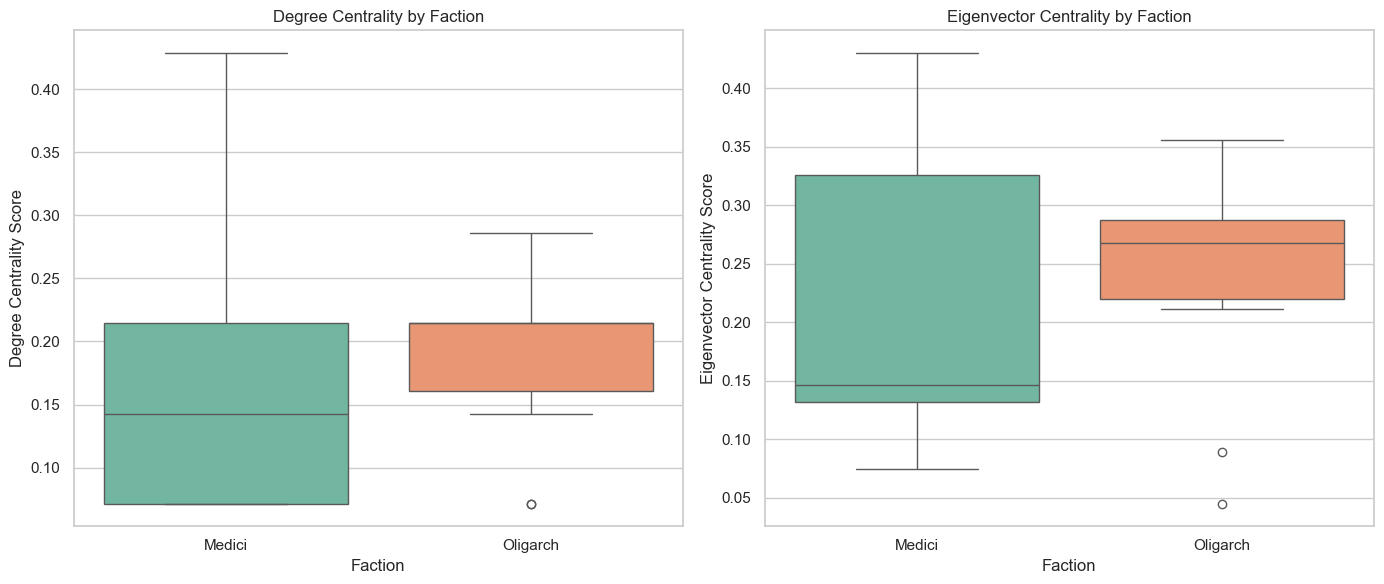

In [9]:
# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for Degree Centrality
sns.boxplot(x='Faction', y='Degree_Centrality', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Degree Centrality by Faction')
axes[0].set_ylabel('Degree Centrality Score')

# Boxplot for Eigenvector Centrality
sns.boxplot(x='Faction', y='Eigenvector_Centrality', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Eigenvector Centrality by Faction')
axes[1].set_ylabel('Eigenvector Centrality Score')

plt.tight_layout()
plt.show()

## Conclusion

After running the independent t-test comparing the average Degree Centrality of the Medici Faction against the Oligarch Faction, the outcome was that I fail to reject the null hypothesis. The data does not support my original prediction that the Medici Faction, as a whole, has a significantly higher average degree centrality. The p-value of the degree of centrality is greater than 0.05, meaning there is no statistically significant difference in the volume of direct connections between the two groups. The boxplots show a wider spread for the Medici faction, with the median sitting a bit low. The Oligarch boxplot is more compact with a higher median. 